In [1]:
import pandas as pd
import numpy as np
import pyreadr
import sys
import os
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from python.disco import DiSCo
from python.data import get_contunious_data, get_discrete_data
from python.visualization import (plot_fit_quantiles, plot_fit_cdf, plot_fit_copula, plot_fit_joint_contour,
plot_fit_scatter2d)

from python.tea import disco_tea

from metrics import calculate_pretreatment_fit

In [2]:
data = pd.read_csv('../datasets/dube_small.csv')

# Univariat
### Wenige Controls

In [3]:
uni_low_contols =  get_contunious_data(1000,num_controls=4, dim=1)

In [4]:
# DiSCo
disco_uni = DiSCo(
    df=data,
    id_col='fips',
    time_col='year',
    y_col='adj0contpov',
    id_col_target=1,     
    t0=2011,             
    M=1000,              
    G=1000,             
    num_cores=1,        
    simplex=True,        
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=False
)
disco_uni = disco_uni.fit()

In [5]:
#mixture
mixture_uni = DiSCo(
    df=data,
    id_col='fips',
    time_col='year',
    y_col='adj0contpov',
    id_col_target=1,     # Spalte '0' als Treatment
    t0=2011,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=1000,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=True
)
mixture_uni = mixture_uni.fit()

c:\Dokumente\Studium\1. Master Thesis\DiSCos\python\solvers.py:282: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=10000, eps=1e-5)


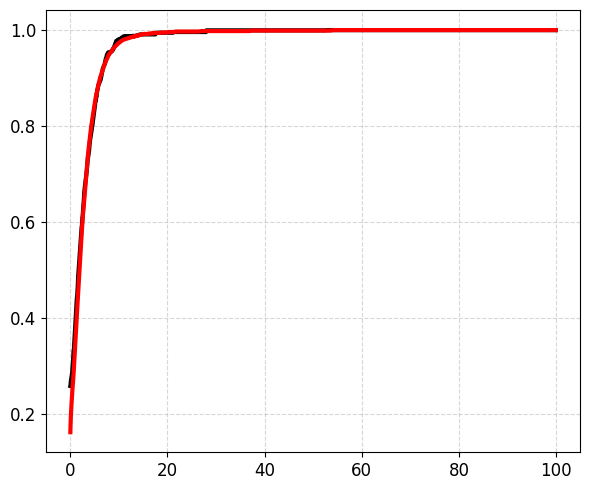

In [6]:
plot_fit_cdf(disco_uni)

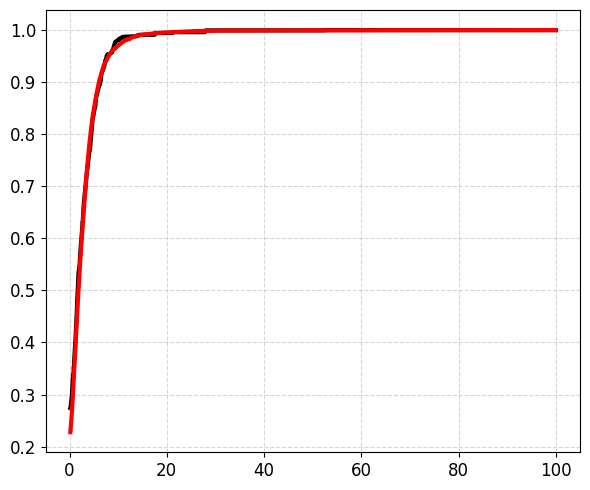

In [7]:
plot_fit_cdf(mixture_uni)

In [8]:
calculate_pretreatment_fit(disco_uni).metrics_per_period[2]

{'w1': 0.14211899286460006,
 'energy_dist': 0.04631744357416973,
 'ks_stat': [np.float64(0.029)],
 'mean_diff': [np.float64(0.04972589040940001)],
 'cov_error': 2.2750594811335993}

In [9]:
calculate_pretreatment_fit(mixture_uni).metrics_per_period[2]

{'w1': 0.16562949131417007,
 'energy_dist': 0.06384018300407966,
 'ks_stat': [np.float64(0.043)],
 'mean_diff': [np.float64(0.0734150974858303)],
 'cov_error': 2.6878119625241546}

# Multivariat
### Wenige Controls

In [10]:
# DiSCo
disco_multi = DiSCo(
    df=data,
    id_col='fips',
    time_col='year',
    y_col=['adj0contpov','age'],
    id_col_target=1,     
    t0=2011,             
    M=1000,              
    G=100,              
    num_cores=-1,        
    simplex=True,        
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=False
)
disco_multi = disco_multi.fit()

In [11]:
#mixture
mixture_multi = DiSCo(
    df=data,
    id_col='fips',
    time_col='year',
    y_col=['adj0contpov','age'],
    id_col_target=1,     # Spalte '0' als Treatment
    t0=2011,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=100,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=True
)
mixture_multi = mixture_multi.fit()

c:\Dokumente\Studium\1. Master Thesis\DiSCos\python\solvers.py:282: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.SCS, max_iters=10000, eps=1e-5)


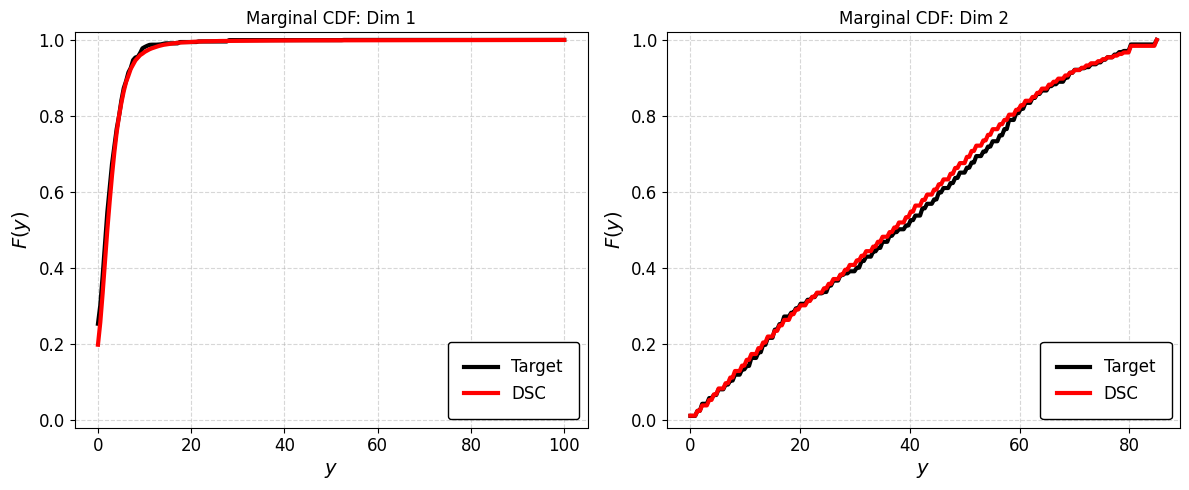

In [12]:
plot_fit_cdf(disco_multi)

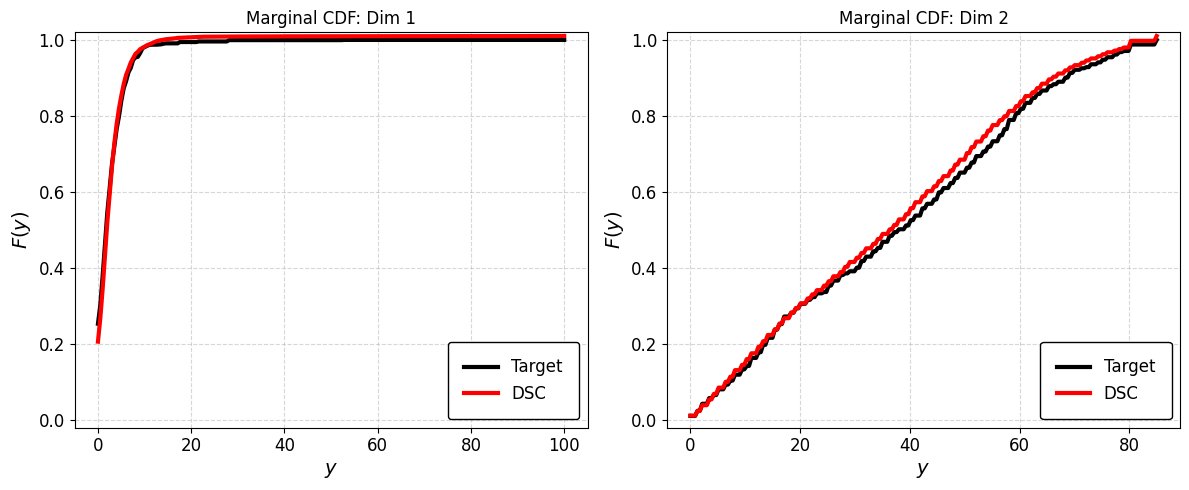

In [13]:
plot_fit_cdf(mixture_multi)

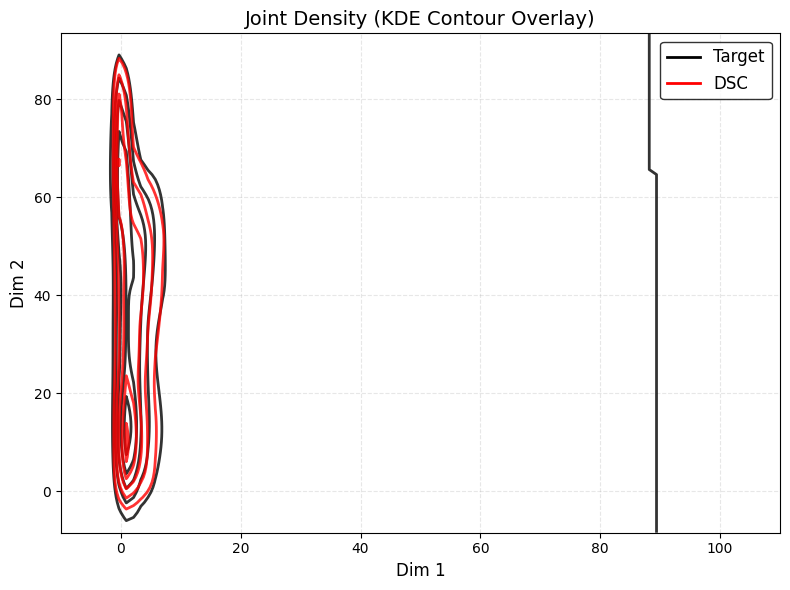

In [14]:
plot_fit_joint_contour(disco_multi)

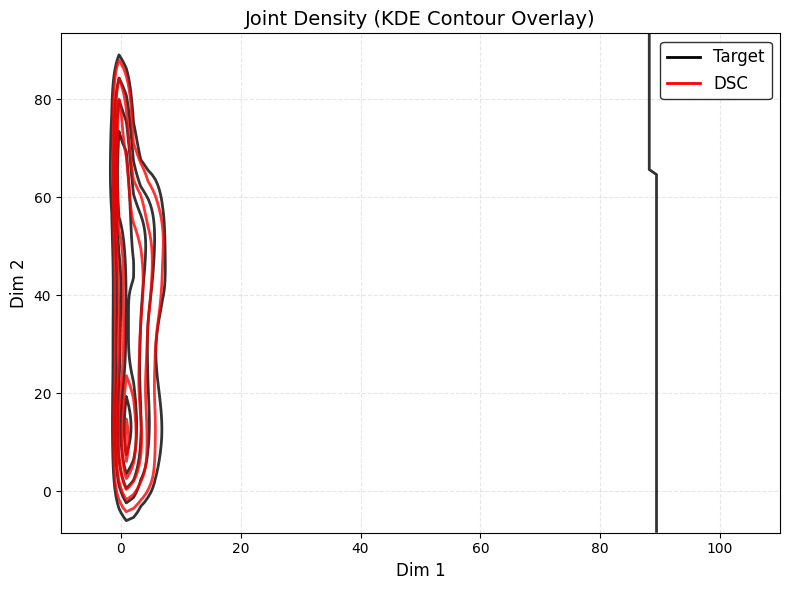

In [15]:
plot_fit_joint_contour(mixture_multi)

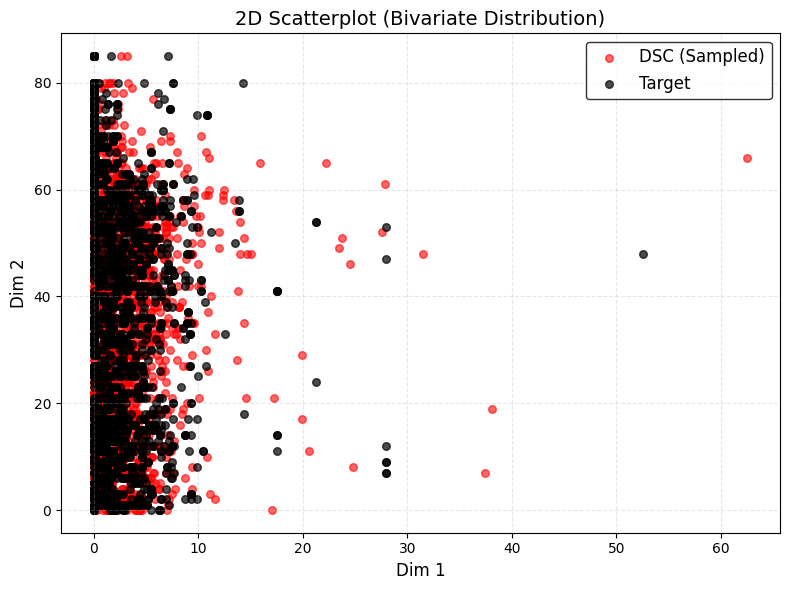

In [16]:
plot_fit_scatter2d(disco_multi)

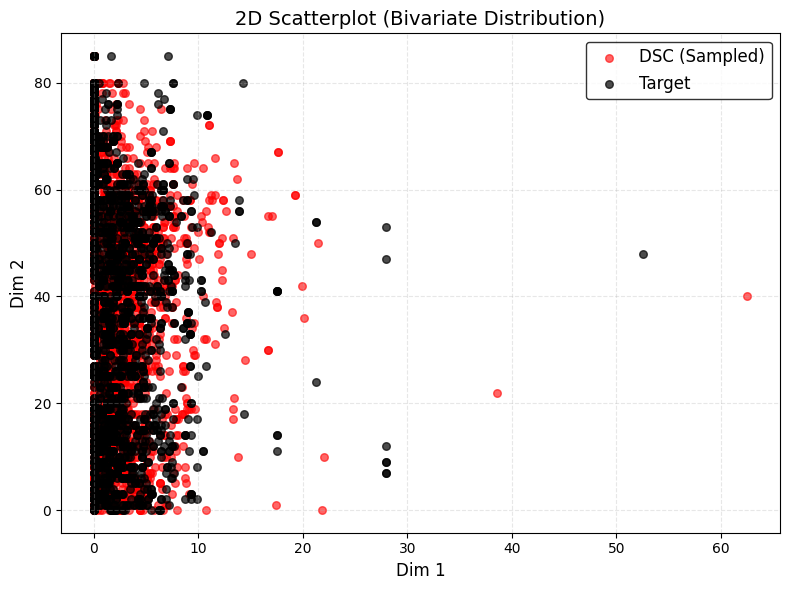

In [17]:
plot_fit_scatter2d(mixture_multi)

In [18]:
calculate_pretreatment_fit(disco_multi).energy_dist

26.240992012991708

In [23]:
calculate_pretreatment_fit(mixture_multi).energy_dist

26.637396174235313

In [20]:
fit_df = mixture_multi.params.df

In [21]:
fit_df.loc[fit_df['year']==2011,'t_col']

306000    4
306001    4
306002    4
306003    4
306004    4
         ..
407995    4
407996    4
407997    4
407998    4
407999    4
Name: t_col, Length: 102000, dtype: int64

# Data

In [22]:
pd.read_csv

<function pandas.read_csv(filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]', *, sep: 'str | None | lib.NoDefault' = <no_default>, delimiter: 'str | None | lib.NoDefault' = None, header: "int | Sequence[int] | None | Literal['infer']" = 'infer', names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>, index_col: 'IndexLabel | Literal[False] | None' = None, usecols: 'UsecolsArgType' = None, dtype: 'DtypeArg | None' = None, engine: 'CSVEngine | None' = None, converters: 'Mapping[HashableT, Callable] | None' = None, true_values: 'list | None' = None, false_values: 'list | None' = None, skipinitialspace: 'bool' = False, skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None, skipfooter: 'int' = 0, nrows: 'int | None' = None, na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None, keep_default_na: 'bool' = True, na_filter: 'bool' = True, skip_blank_lines: 'bool' = True, parse_dates: 'bool | Sequence[